In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets  import mnist
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import (Conv2D, MaxPooling2D, Flatten,
                                           Dense, Dropout, BatchNormalization)
from tensorflow.keras.utils     import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics            import classification_report, confusion_matrix
import tensorflow as tf, warnings
warnings.filterwarnings('ignore')

print(f"✓ TensorFlow {tf.__version__}")

✓ TensorFlow 2.20.0


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)

100%|██████████| 1.24G/1.24G [00:14<00:00, 89.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/crawford/emnist/versions/3


In [3]:
import os
import numpy as np
import pandas as pd

DATA_PATH = '/root/.cache/kagglehub/datasets/crawford/emnist/versions/3'

for f in os.listdir(DATA_PATH):
    print(f)

emnist-letters-mapping.txt
emnist-letters-train.csv
emnist-bymerge-test.csv
emnist-bymerge-mapping.txt
emnist-balanced-test.csv
emnist-mnist-mapping.txt
emnist-mnist-train.csv
emnist-byclass-test.csv
emnist-mnist-test.csv
emnist_source_files
emnist-byclass-train.csv
emnist-balanced-train.csv
emnist-byclass-mapping.txt
emnist-digits-mapping.txt
emnist-digits-train.csv
emnist-letters-test.csv
emnist-bymerge-train.csv
emnist-digits-test.csv
emnist-balanced-mapping.txt


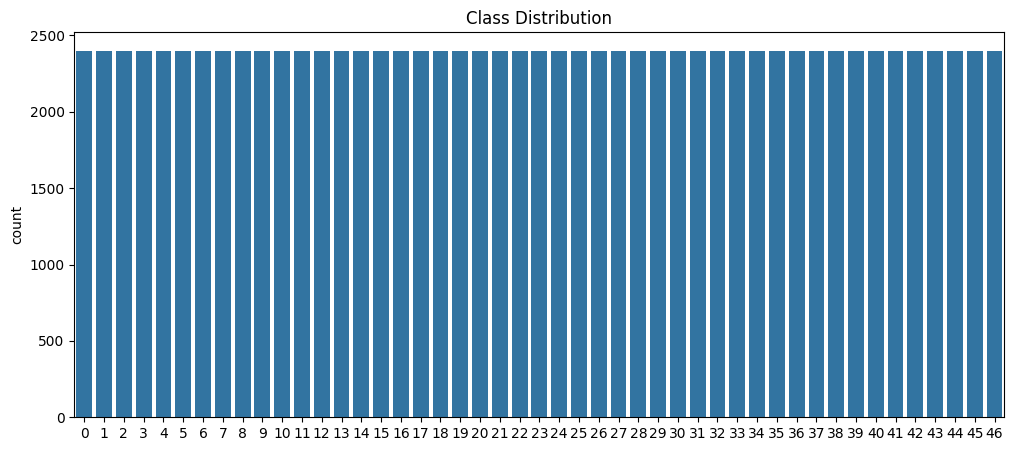

In [12]:
plt.figure(figsize=(12,5))
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

In [4]:
print("Loading train... (1 min)")
train = pd.read_csv(f'{DATA_PATH}/emnist-balanced-train.csv', header=None)
test  = pd.read_csv(f'{DATA_PATH}/emnist-balanced-test.csv',  header=None)

y_train = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values.reshape(-1, 28, 28)

y_test  = test.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.reshape(-1, 28, 28)

X_train = np.flip(X_train, axis=2)
X_test  = np.flip(X_test,  axis=2)

NUM_CLASSES = 47
LABEL_MAP = (list('0123456789') +
             list('ABCDEFGHIJKLMNOPQRSTUVWXYZ') +
             list('abdefghnqrt'))

print(f"✓ Train: {X_train.shape}")
print(f"✓ Test : {X_test.shape}")
print(f"✓ Classes: {NUM_CLASSES}")

Loading train... (1 min)
✓ Train: (112800, 28, 28)
✓ Test : (18800, 28, 28)
✓ Classes: 47


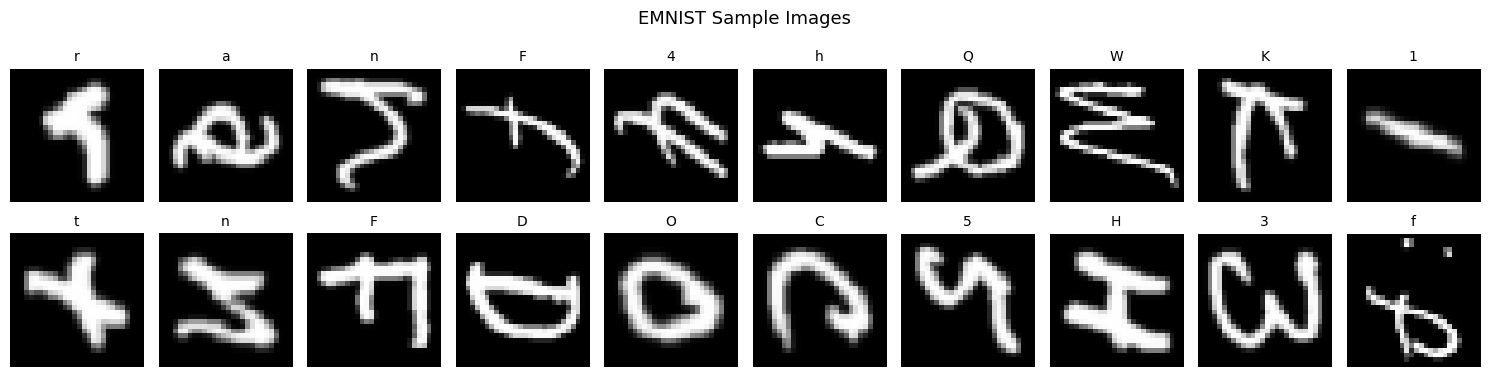

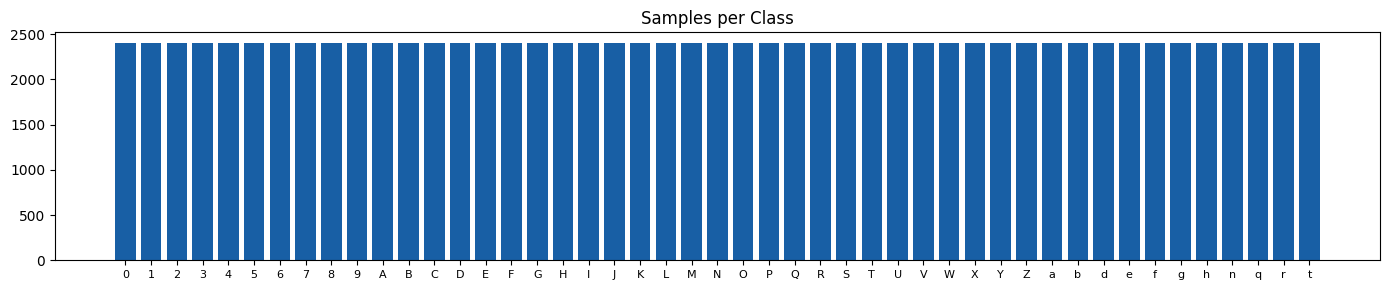

In [5]:
LABEL_MAP = (list('0123456789') +
             list('ABCDEFGHIJKLMNOPQRSTUVWXYZ') +
             list('abdefghnqrt'))   # 47 merged classes

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(LABEL_MAP[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('EMNIST Sample Images', fontsize=13)
plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 3))
plt.bar(range(NUM_CLASSES), np.bincount(y_train), color='#185fa5')
plt.xticks(range(NUM_CLASSES), LABEL_MAP, fontsize=8)
plt.title('Samples per Class'); plt.tight_layout(); plt.show()

In [6]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"X_train: {X_train.shape}  y_train: {y_train_cat.shape}")

X_train: (112800, 28, 28, 1)  y_train: (112800, 47)


In [7]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),  Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),  Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),  Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,487 (1.81 MB)

 Trainable params: 473,039 (1.80 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 405s 510ms/step - accuracy: 0.8763 - loss: 0.3500 - val_accuracy: 0.8845 - val_loss: 0.3173
Epoch 2/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 411s 518ms/step - accuracy: 0.8805 - loss: 0.3382 - val_accuracy: 0.8872 - val_loss: 0.3045
Epoch 3/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 447s 524ms/step - accuracy: 0.8823 - loss: 0.3289 - val_accuracy: 0.8889 - val_loss: 0.3087
Epoch 4/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 418s 526ms/step - accuracy: 0.8857 - loss: 0.3190 - val_accuracy: 0.8903 - val_loss: 0.3027
Epoch 5/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 442s 526ms/step - accuracy: 0.8868 - loss: 0.3158 - val_accuracy: 0.8919 - val_loss: 0.2977
Epoch 6/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 406s 512ms/step - accuracy: 0.8879 - loss: 0.3087 - val_accuracy: 0.8887 - val_loss: 0.3170
Epoch 7/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 443s 513ms/step - accuracy: 0.8888 - loss: 0.3076 - val_accuracy: 0.8907 - val_loss: 0.3009
Epoch 8/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 426s 536ms/step - accuracy: 0.8907 -

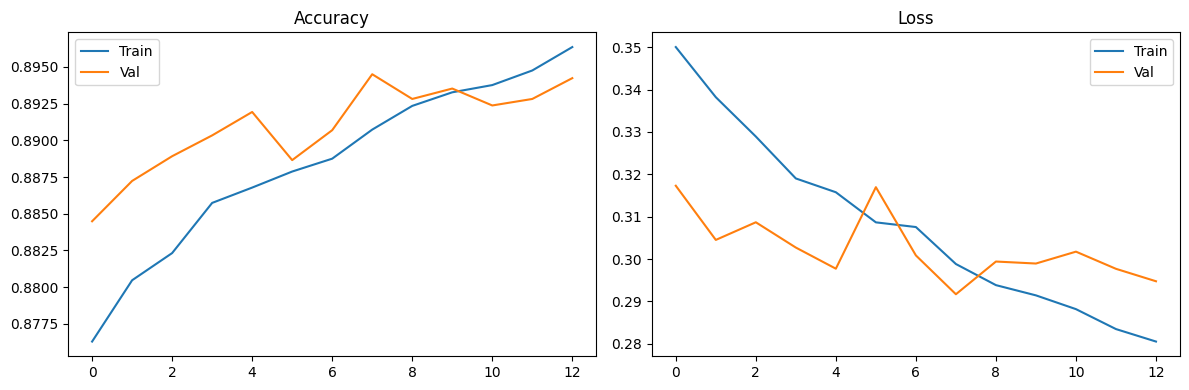

In [9]:
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_accuracy',
                              patience=5,
                              restore_best_weights=True)],
    verbose=1
)

# Plot accuracy & loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history.history[metric],       label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(metric.capitalize())
    ax.legend()
plt.tight_layout(); plt.show()

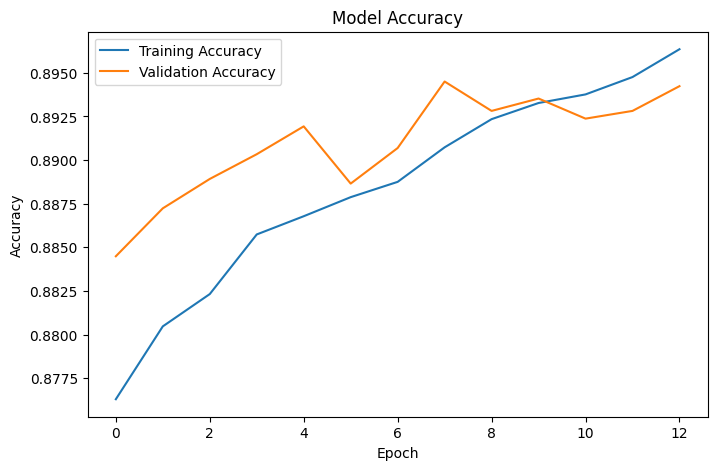

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

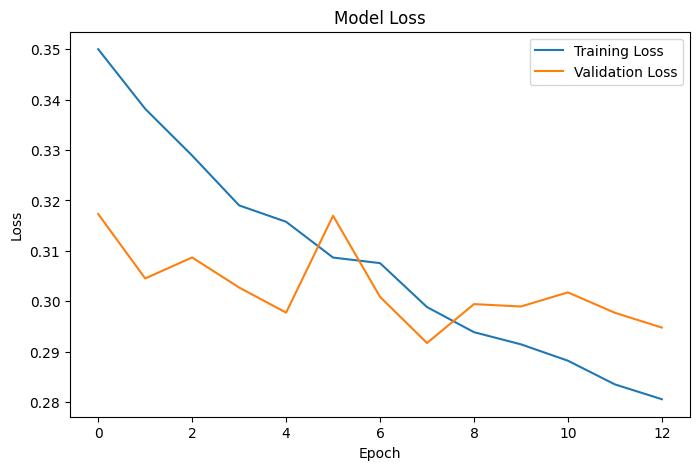

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Test Accuracy: 89.31%
588/588 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step
              precision    recall  f1-score   support

           0       0.65      0.73      0.69       400
           1       0.51      0.88      0.64       400
           2       0.89      0.93      0.91       400
           3       0.99      0.99      0.99       400
           4       0.97      0.93      0.95       400
           5       0.97      0.90      0.94       400
           6       0.96      0.92      0.94       400
           7       0.98      0.99      0.99       400
           8       0.97      0.95      0.96       400
           9       0.73      0.76      0.75       400
           A       0.96      0.99      0.98       400
           B       0.97      0.98      0.98       400
           C       0.96      0.97      0.96       400
           D       0.94      0.91      0.92       400
           E       0.98      0.99      0.99       400
           F       0.72      0.56      0.63       400
           G    

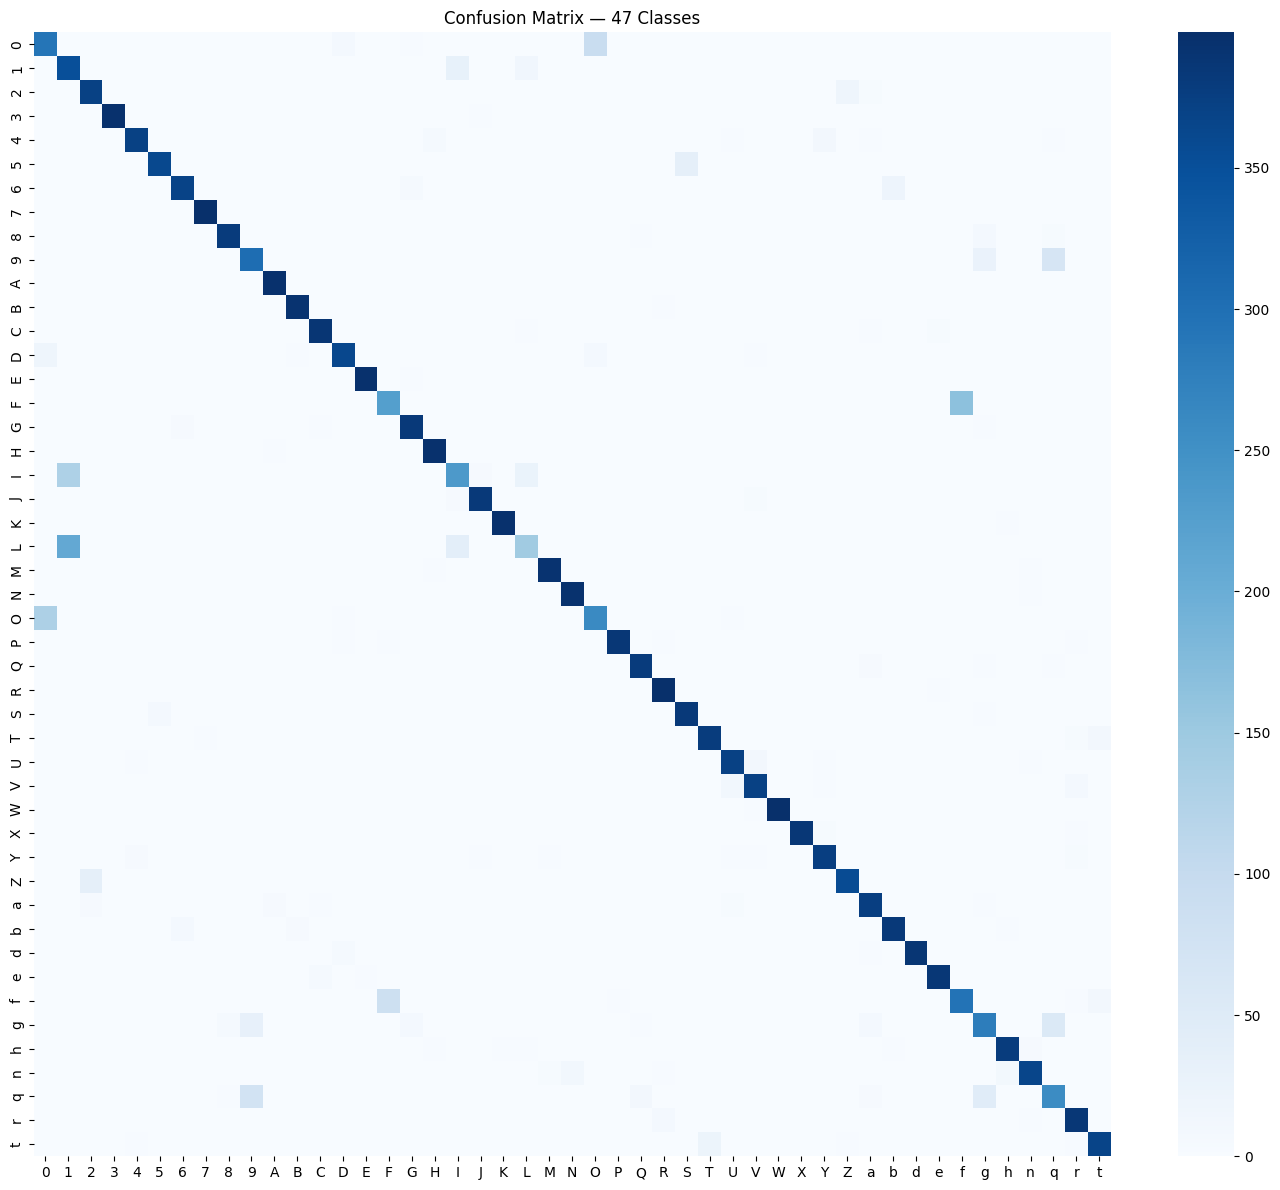

✓ Model saved → emnist_cnn.h5


In [10]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {acc:.2%}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred,
      target_names=[str(LABEL_MAP[i]) for i in range(NUM_CLASSES)]))

# Confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(confusion_matrix(y_test, y_pred),
            cmap='Blues', xticklabels=LABEL_MAP, yticklabels=LABEL_MAP)
plt.title('Confusion Matrix — 47 Classes')
plt.tight_layout(); plt.show()

# Save model
model.save('emnist_cnn.h5')
print("✓ Model saved → emnist_cnn.h5")

Predicted : Q
Confidence: 100.0%


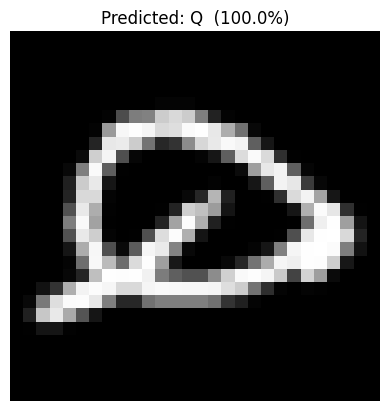

True label: Q

Predicted : W
Confidence: 100.0%


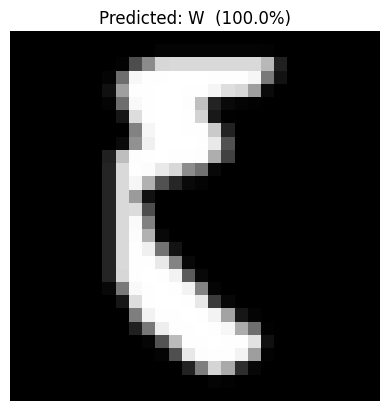

True label: W

Predicted : Y
Confidence: 99.5%


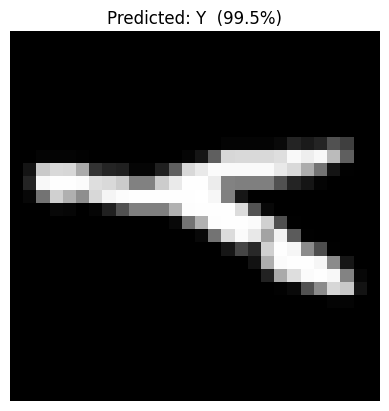

True label: Y

Predicted : b
Confidence: 95.2%


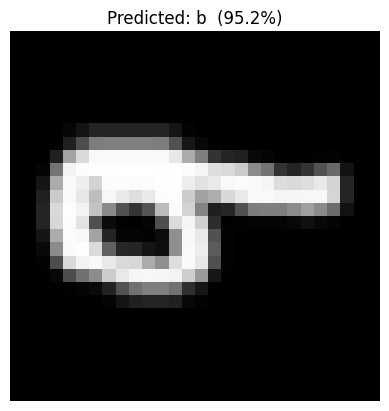

True label: 6

Predicted : 6
Confidence: 80.9%


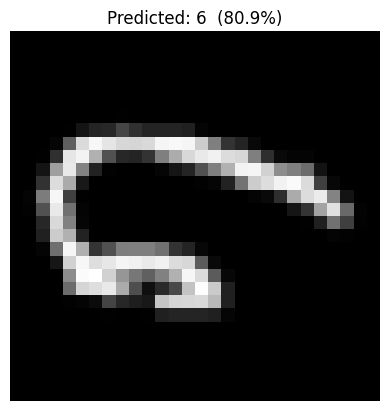

True label: 6



In [11]:
def predict_char(img_array):
    img = img_array.reshape(1, 28, 28, 1).astype('float32') / 255.0
    prob = model.predict(img, verbose=0)[0]
    idx  = np.argmax(prob)
    print(f"Predicted : {LABEL_MAP[idx]}")
    print(f"Confidence: {prob[idx]:.1%}")

    # Show the image
    plt.imshow(img_array.squeeze(), cmap='gray')
    plt.title(f'Predicted: {LABEL_MAP[idx]}  ({prob[idx]:.1%})')
    plt.axis('off'); plt.show()

# Test on random test samples
for i in np.random.choice(len(X_test), 5):
    predict_char(X_test[i] * 255)
    print(f"True label: {LABEL_MAP[y_test[i]]}\n")

In [16]:
model.save("handwritten_character_model.h5")